# Imperial Project 2026

## Tactical Analysis in Football
---

Acknowledgement: All core analysis and implementation have been carried out independently.

---

### Table of Contents

<summary><b> Single-Match Analysis</b></summary>

    - Table results of all the stats for the matches // divided by Women and Men football
    - SBM - findings on the number of blocks - distribution - one example of graph with the block

<summary><b> Multi-Match Analysis</b></summary>

    - clustering model results - Radar plot for each 3 methods
    - table to compare the clustering methods
    - xG model comparison vs Random forest


In [1]:
#import necessary packages

from statsbombpy import sb
import mplsoccer
from mplsoccer import Pitch
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from networkx.algorithms.community import kernighan_lin_bisection
from networkx.algorithms.community import modularity
from networkx.algorithms.community import girvan_newman
import random
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from networkx.algorithms.triads import triadic_census
from collections import defaultdict
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.manifold import TSNE
import os
os.environ['KERAS_BACKEND']='tensorflow'
import keras
import tensorflow as tf
from keras.layers import Layer, Dense, Reshape
from keras.models import Model
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from scipy.spatial.distance import cdist

from keras.callbacks import EarlyStopping

from pathlib import Path
from collections import Counter

from scipy.stats import spearmanr, pearsonr

c:\Users\8andr\OneDrive\Desktop\Imperial_College_University\VS_Code\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [ ]:
# run the setup notebook
%run Imperial_Project_2026_code_Setup.ipynb

### Choose the competitions to be analysed

In [3]:
#Example of competition data set
competitions = sb.competitions()

In [8]:
competitions[:20]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,None,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882
5,16,2,Europe,Champions League,male,False,False,2016/2017,2024-02-13T02:37:32.205154,2021-06-13T16:17:31.694,None,2024-02-13T02:37:32.205154
6,16,27,Europe,Champions League,male,False,False,2015/2016,2024-06-12T07:45:38.786894,2021-06-13T16:17:31.694,None,2024-06-12T07:45:38.786894
7,16,26,Europe,Champions League,male,False,False,2014/2015,2024-02-12T12:49:54.914228,2021-06-13T16:17:31.694,None,2024-02-12T12:49:54.914228
8,16,25,Europe,Champions League,male,False,False,2013/2014,2024-02-12T12:48:48.479157,2021-06-13T16:17:31.694,None,2024-02-12T12:48:48.479157
9,16,24,Europe,Champions League,male,False,False,2012/2013,2024-02-12T12:47:34.340413,2021-06-13T16:17:31.694,None,2024-02-12T12:47:34.340413


In [9]:
competitions[20:40]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
20,16,276,Europe,Champions League,male,False,False,1970/1971,2024-02-13T14:24:12.213582,None,None,2024-02-13T14:24:12.213582
21,223,282,South America,Copa America,male,False,True,2024,2026-05-13T12:24:48.807600,None,None,2026-05-13T12:24:48.807600
22,87,84,Spain,Copa del Rey,male,False,False,1983/1984,2024-02-13T01:54:12.946985,2021-06-13T16:17:31.694,None,2024-02-13T01:54:12.946985
23,87,268,Spain,Copa del Rey,male,False,False,1982/1983,2024-02-13T14:19:57.954551,None,None,2024-02-13T14:19:57.954551
24,87,279,Spain,Copa del Rey,male,False,False,1977/1978,2024-02-13T14:26:19.978418,None,None,2024-02-13T14:26:19.978418
25,37,281,England,FA Women's Super League,female,False,False,2023/2024,2026-04-11T13:05:10.794831,None,None,2026-04-11T13:05:10.794831
26,37,90,England,FA Women's Super League,female,False,False,2020/2021,2026-04-12T16:33:48.145602,2021-06-13T16:17:31.694,None,2026-04-12T16:33:48.145602
27,37,42,England,FA Women's Super League,female,False,False,2019/2020,2026-04-12T16:07:56.102610,2021-06-13T16:17:31.694,None,2026-04-12T16:07:56.102610
28,37,4,England,FA Women's Super League,female,False,False,2018/2019,2026-03-28T18:13:53.368475,2021-06-13T16:17:31.694,None,2026-03-28T18:13:53.368475
29,1470,274,International,FIFA U20 World Cup,male,True,True,1979,2024-02-13T14:20:59.825440,None,None,2024-02-13T14:20:59.825440


In [10]:
competitions[40:60]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
40,11,90,Spain,La Liga,male,False,False,2020/2021,2025-11-02T03:55:19.577958,2025-11-02T03:55:53.923193,2025-11-02T03:55:53.923193,2025-11-02T03:55:19.577958
41,11,42,Spain,La Liga,male,False,False,2019/2020,2024-12-16T16:51:06.833054,2021-06-13T16:17:31.694,None,2024-12-16T16:51:06.833054
42,11,4,Spain,La Liga,male,False,False,2018/2019,2026-04-06T04:49:09.959011,2021-07-09T14:53:22.103024,None,2026-04-06T04:49:09.959011
43,11,1,Spain,La Liga,male,False,False,2017/2018,2025-07-14T10:01:16.674864,2021-06-13T16:17:31.694,None,2025-07-14T10:01:16.674864
44,11,2,Spain,La Liga,male,False,False,2016/2017,2025-03-09T16:03:54.962718,2021-06-13T16:17:31.694,None,2025-03-09T16:03:54.962718
45,11,27,Spain,La Liga,male,False,False,2015/2016,2025-04-23T13:59:22.835792,2021-06-13T16:17:31.694,None,2025-04-23T13:59:22.835792
46,11,26,Spain,La Liga,male,False,False,2014/2015,2025-06-24T13:39:01.068680,2021-06-13T16:17:31.694,None,2025-06-24T13:39:01.068680
47,11,25,Spain,La Liga,male,False,False,2013/2014,2025-06-24T09:52:44.048585,2021-06-13T16:17:31.694,None,2025-06-24T09:52:44.048585
48,11,24,Spain,La Liga,male,False,False,2012/2013,2025-06-24T13:53:14.047130,2021-06-13T16:17:31.694,None,2025-06-24T13:53:14.047130
49,11,23,Spain,La Liga,male,False,False,2011/2012,2025-06-24T13:38:10.764259,2021-06-13T16:17:31.694,None,2025-06-24T13:38:10.764259


In [11]:
competitions[60:80]

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
60,81,275,Argentina,Liga Profesional,male,False,False,1981,2023-12-05T14:19:40.272816,None,None,2023-12-05T14:19:40.272816
61,7,235,France,Ligue 1,male,False,False,2022/2023,2026-04-06T18:51:07.770289,2026-04-06T18:59:05.942748,2026-04-06T18:59:05.942748,2026-04-06T18:51:07.770289
62,7,108,France,Ligue 1,male,False,False,2021/2022,2026-04-25T22:22:46.370056,2026-04-25T22:24:04.840827,2026-04-25T22:24:04.840827,2026-04-25T22:22:46.370056
63,7,27,France,Ligue 1,male,False,False,2015/2016,2026-05-12T22:46:54.722768,None,None,2026-05-12T22:46:54.722768
64,44,107,United States of America,Major League Soccer,male,False,False,2023,2026-02-05T12:10:54.420133,2026-02-05T12:11:58.293463,2026-02-05T12:11:58.293463,2026-02-05T12:10:54.420133
65,116,68,North and Central America,North American League,male,False,False,1977,2025-02-20T11:41:45.243252,2021-06-13T16:17:31.694,None,2025-02-20T11:41:45.243252
66,49,107,United States of America,NWSL,female,False,False,2023,2026-04-08T09:41:46.347347,None,None,2026-04-08T09:41:46.347347
67,49,3,United States of America,NWSL,female,False,False,2018,2024-12-15T12:31:48.035735,2021-06-13T16:17:31.694,None,2024-12-15T12:31:48.035735
68,2,27,England,Premier League,male,False,False,2015/2016,2025-12-17T14:38:00.447595,2021-06-13T16:17:31.694,None,2025-12-17T14:38:00.447595
69,2,44,England,Premier League,male,False,False,2003/2004,2025-06-24T13:53:07.585114,2021-06-13T16:17:31.694,None,2025-06-24T13:53:07.585114


In [3]:
matches1 = sb.matches(competition_id=37,season_id=281)
matches2 = sb.matches(competition_id=135,season_id=281)
matches3 = sb.matches(competition_id=182,season_id=281)
matches4 = sb.matches(competition_id=131,season_id=281)
all_matches_female = pd.concat([matches1,matches2,matches3,matches4])
all_matches_female['competition_gender'] = 'female'

In [4]:
matches2 = sb.matches(competition_id=7,season_id=27)
matches3 = sb.matches(competition_id=11,season_id=27)
matches4 = sb.matches(competition_id=2,season_id=27)
matches5 = sb.matches(competition_id=12,season_id=27)
all_matches_male = pd.concat([matches2,matches3,matches4,matches5])
all_matches_male['competition_gender'] = 'male'

In [5]:
all_matches = pd.concat([all_matches_female,all_matches_male])

### Table results of all the stats for the matches // divided by Women and Men football

In [15]:
G_all_matches_dist_male = build_features_graph(matches=all_matches_male,G_gen = G_dist_gen)

# Folder used to store processed datasets
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# File path
features_path = output_dir / "male_match_graph_features.parquet"


# Save dataframe
G_all_matches_dist_male.to_parquet(
    features_path,
    index=False
)

print(f"Features saved to: {features_path.resolve()}")
print(f"Shape: {G_all_matches_dist_male.shape}")

Features saved to: C:\Users\8andr\OneDrive\Desktop\Imperial_College_University\AA_2025-26\MATH70105_Machine_Learning_and_Data_Science_Research_Project\zz_Project\01.Code\data\processed\male_match_graph_features.parquet
Shape: (3034, 38)


In [ ]:
#Upload the saved dataframe

features_path = Path("data/processed/male_match_graph_features.parquet")

G_all_matches_dist_male = pd.read_parquet(features_path)

print(G_all_matches_dist_male.shape)
G_all_matches_dist_male.head()

(3034, 38)


,number_of_players,number_of_edges,num_passes,density,average_degree,degree_centralization,average_clustering,modularity,number_of_communities,average_path_length,...,triad_300_norm,entropy_motif,xg_team_match,match_id,team_id,team_name,competition,score,home_dummy,competition_gender
0,14,115,397,0.631868,16.428571,0.500000,0.864954,0.138568,3,1.831691,...,0.214286,2.331735,0.977295,3901259,133,Troyes,France - Ligue 1,1,1,male
1,14,128,560,0.703297,18.285714,0.512821,0.853705,0.145153,3,3.353936,...,0.241758,2.191558,2.512848,3901259,147,Olympique de Marseille,France - Ligue 1,1,0,male
2,14,125,512,0.686813,17.857143,0.461538,0.880314,0.181123,3,2.627669,...,0.302198,2.128395,0.967394,3900533,129,AS Monaco,France - Ligue 1,1,1,male
3,13,93,277,0.596154,14.307692,0.462121,0.799828,0.120930,3,1.737297,...,0.132867,2.521592,0.474913,3900533,140,Stade Malherbe Caen,France - Ligue 1,1,0,male
4,14,131,540,0.719780,18.714286,0.564103,0.888342,0.107222,2,2.350952,...,0.299451,2.193078,0.767266,3900528,146,Bordeaux,France - Ligue 1,1,1,male


In [51]:
G_all_matches_dist_female = build_features_graph(matches=all_matches_female,G_gen = G_dist_gen)

# Folder used to store processed datasets
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# File path
features_path = output_dir / "female_match_graph_features.parquet"

# Save dataframe
G_all_matches_dist_female.to_parquet(
    features_path,
    index=False
)

print(f"Features saved to: {features_path.resolve()}")
print(f"Shape: {G_all_matches_dist_female.shape}")

Features saved to: C:\Users\8andr\OneDrive\Desktop\Imperial_College_University\AA_2025-26\MATH70105_Machine_Learning_and_Data_Science_Research_Project\zz_Project\01.Code\data\processed\female_match_graph_features.parquet
Shape: (1268, 38)


In [ ]:
#Upload the saved dataframe

features_path = Path("data/processed/female_match_graph_features.parquet")

G_all_matches_dist_female = pd.read_parquet(features_path)

print(G_all_matches_dist_female.shape)
G_all_matches_dist_female.head()

(1268, 38)


,number_of_players,number_of_edges,num_passes,density,average_degree,degree_centralization,average_clustering,modularity,number_of_communities,average_path_length,...,triad_300_norm,entropy_motif,xg_team_match,match_id,team_id,team_name,competition,score,home_dummy,competition_gender
0,16,104,204,0.433333,13.000000,0.533333,0.626123,0.126553,3,1.364610,...,0.039286,2.465090,1.233260,3913082,965,Brighton & Hove Albion WFC,England - FA Women's Super League,2,1,female
1,14,104,457,0.571429,14.857143,0.820513,0.860506,0.159028,3,2.067846,...,0.159341,2.367157,3.043344,3913082,1475,Manchester United W,England - FA Women's Super League,2,0,female
2,13,102,429,0.653846,15.692308,0.424242,0.885936,0.142375,3,2.019442,...,0.216783,2.291726,2.125410,3913155,746,Manchester City WFC,England - FA Women's Super League,3,1,female
3,14,100,368,0.549451,14.285714,0.602564,0.756597,0.139643,3,1.842819,...,0.104396,2.548667,1.133832,3913155,1475,Manchester United W,England - FA Women's Super League,1,0,female
4,16,144,568,0.600000,18.000000,0.838095,0.818317,0.143370,3,2.308337,...,0.173214,2.256565,1.705603,3913167,1475,Manchester United W,England - FA Women's Super League,2,1,female


In [ ]:
#All dataframe combined

G_all_matches_dist = pd.concat([G_all_matches_dist_male,G_all_matches_dist_female])

In [56]:
for gen in G_all_matches_dist['competition_gender'].unique():
    for comp in G_all_matches_dist[G_all_matches_dist['competition_gender'] == gen]['competition'].unique():
            n_match = G_all_matches_dist[(G_all_matches_dist['competition'] == comp) & (G_all_matches_dist['competition_gender'] == gen)]
            print(f'The {comp} gender {gen}: n_matches {len(n_match)/2}')

The France - Ligue 1 gender male: n_matches 377.0
The Spain - La Liga gender male: n_matches 380.0
The England - Premier League gender male: n_matches 380.0
The Italy - Serie A gender male: n_matches 380.0
The England - FA Women's Super League gender female: n_matches 132.0
The Germany - Frauen Bundesliga gender female: n_matches 132.0
The Spain - Liga F gender female: n_matches 240.0
The Italy - Serie A Women gender female: n_matches 130.0


In [9]:
columns = ['number_of_players',  'num_passes', 'density',
       'average_degree', 'degree_centralization', 'average_clustering',
       'modularity',  'average_path_length',
       'betweenness_sd', 'algebraic_connectivity', 'degree_assortativity','entropy_motif']

stats=G_all_matches_dist[columns]

In [ ]:
def summarize_features(features_df):
    """
    Calculate count, mean, standard deviation, median, minimum and maximum
    for selected features within each group.
    """

    summary = (
        features_df
        .agg(["mean", "std", "median", "min", "max"])
    )

    return summary.round(2).T

In [11]:
stats_comparision = summarize_features(stats).rename(columns={
    "mean": "Mean",
    "std": "SD",
    "min": "Min",
    "median": "Median",
    "max": "Max"
})

In [ ]:
#Display the result

stats_comparision

,Mean,SD,Median,Min,Max
number_of_players,14.07,0.94,14.00,11.00,16.00
num_passes,368.89,121.51,354.00,91.00,855.00
density,0.59,0.08,0.60,0.26,0.85
average_degree,15.40,1.75,15.54,6.92,20.43
degree_centralization,0.61,0.12,0.60,0.18,1.09
average_clustering,0.81,0.06,0.82,0.45,0.96
modularity,0.13,0.03,0.13,0.04,0.29
average_path_length,2.01,0.62,1.91,0.72,6.03
betweenness_sd,0.10,0.02,0.10,0.05,0.21
algebraic_connectivity,2.41,0.76,2.45,0.23,4.78


In [25]:
columns = ['number_of_players',  'num_passes', 'density',
       'average_degree', 'degree_centralization', 'average_clustering',
       'modularity',  'average_path_length',
       'betweenness_sd', 'algebraic_connectivity', 'degree_assortativity','entropy_motif','competition_gender']

stats=G_all_matches_dist[columns]

In [ ]:
#Women & Men Football table summary


gender_feature_summary = summarize_features_by_gender(
    features_df=stats,
    gender_column="competition_gender",
    feature_columns=columns[:-1],
    round_digits=2
)


gender_comparison = create_gender_comparison_table(gender_feature_summary)

gender_comparison_compact = create_compact_gender_table(
    gender_comparison,
    decimals=2
)

In [27]:
feature_labels = {
    "number_of_players": "Number of Nodes",
    "num_passes": "Number of Passes",
    "density": "Density",
    "average_degree": "Average Degree",
    "degree_centralization": "Degree Centralization",
    "average_clustering": "Average Clustering",
    "modularity": "Modularity",
    "average_path_length": "Average Path Length",
    "betweenness_sd": "Betweenness SD",
    "algebraic_connectivity": "Algebraic Connectivity",
    "degree_assortativity": "Degree Assortativity",
    "entropy_motif": "Motif Entropy"
}

gender_comparison_compact["Feature"] = (
    gender_comparison_compact["Feature"]
    .replace(feature_labels)
)


feature_order = [
    "Number of Nodes",
    "Number of Passes",
    "Density",
    "Average Degree",
    "Degree Centralization",
    "Average Clustering",
    "Modularity",
    "Average Path Length",
    "Betweenness SD",
    "Algebraic Connectivity",
    "Degree Assortativity",
    "Motif Entropy"
]

gender_comparison_compact["Feature"] = pd.Categorical(
    gender_comparison_compact["Feature"],
    categories=feature_order,
    ordered=True
)

gender_comparison_compact = (
    gender_comparison_compact
    .sort_values("Feature")
    .reset_index(drop=True)
)

In [ ]:
# Display the result

gender_comparison_compact

,Feature,Female Mean ± SD,Male Mean ± SD
0,Number of Nodes,14.94 ± 1.08,13.71 ± 0.55
1,Number of Passes,355.57 ± 131.51,374.46 ± 116.65
2,Density,0.53 ± 0.08,0.62 ± 0.07
3,Average Degree,14.81 ± 1.93,15.65 ± 1.61
4,Degree Centralization,0.64 ± 0.13,0.60 ± 0.12
5,Average Clustering,0.78 ± 0.06,0.82 ± 0.05
6,Modularity,0.14 ± 0.03,0.13 ± 0.03
7,Average Path Length,1.72 ± 0.53,2.13 ± 0.61
8,Betweenness SD,0.11 ± 0.02,0.10 ± 0.02
9,Algebraic Connectivity,2.23 ± 0.77,2.49 ± 0.74


### SBM - findings on the number of blocks - distribution - one example of graph with the block

In [ ]:
# code about SBM - Men football

male_sbm_features = build_dc_sbm_features(matches = all_matches_male,G_gen=G_dist_gen)

# Folder used to store processed datasets
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# File path
features_path = output_dir / "male_sbm_features.parquet"


# Save dataframe
male_sbm_features.to_parquet(
    features_path,
    index=False
)

print(f"Features saved to: {features_path.resolve()}")
print(f"Shape: {male_sbm_features.shape}")

Features saved to: C:\Users\8andr\OneDrive\Desktop\Imperial_College_University\AA_2025-26\MATH70105_Machine_Learning_and_Data_Science_Research_Project\zz_Project\01.Code\data\processed\male_sbm_features.parquet
Shape: (3034, 16)


In [ ]:
#Upload the saved dataframe

features_path = Path("data/processed/male_sbm_features.parquet")

male_sbm_features = pd.read_parquet(features_path)

print(male_sbm_features.shape)
male_sbm_features.head()

(3034, 16)


,match_id,team_id,team_name,competition,competition_gender,home_dummy,score,xg_team_match,number_of_players,initial_log_likelihood,final_log_likelihood,likelihood_improvement,normalised_final_log_likelihood,number_of_final_blocks,total_passes,number_iteration
0,3901259,133,Troyes,France - Ligue 1,male,1,1,0.977295,14,-2905.158078,-2880.263243,24.894835,-7.255071,4,397.0,4
1,3901259,147,Olympique de Marseille,France - Ligue 1,male,0,1,2.512848,14,-4252.017404,-4199.452520,52.564884,-7.499022,5,560.0,4
2,3900533,129,AS Monaco,France - Ligue 1,male,1,1,0.967394,14,-3898.964569,-3898.964569,0.000000,-7.615165,2,512.0,1
3,3900533,140,Stade Malherbe Caen,France - Ligue 1,male,0,1,0.474913,13,-1934.506271,-1912.359846,22.146425,-6.903826,3,277.0,3
4,3900528,146,Bordeaux,France - Ligue 1,male,1,1,0.767266,14,-4132.999887,-4098.728166,34.271721,-7.590237,3,540.0,4


In [ ]:
# code about SBM - Women football

female_sbm_features = build_dc_sbm_features(matches = all_matches_female,G_gen=G_dist_gen)

# Folder used to store processed datasets
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# File path
features_path = output_dir / "female_sbm_features.parquet"


# Save dataframe
female_sbm_features.to_parquet(
    features_path,
    index=False
)

print(f"Features saved to: {features_path.resolve()}")
print(f"Shape: {female_sbm_features.shape}")

Features saved to: C:\Users\8andr\OneDrive\Desktop\Imperial_College_University\AA_2025-26\MATH70105_Machine_Learning_and_Data_Science_Research_Project\zz_Project\01.Code\data\processed\female_sbm_features.parquet
Shape: (1268, 16)


In [ ]:
#Upload the saved dataframe

features_path = Path("data/processed/female_sbm_features.parquet")

female_sbm_features = pd.read_parquet(features_path)

print(female_sbm_features.shape)
female_sbm_features.head()

(1268, 16)


,match_id,team_id,team_name,competition,competition_gender,home_dummy,score,xg_team_match,number_of_players,initial_log_likelihood,final_log_likelihood,likelihood_improvement,normalised_final_log_likelihood,number_of_final_blocks,total_passes,number_iteration
0,3913082,965,Brighton & Hove Albion WFC,England - FA Women's Super League,female,1,2,1.233260,16,-1345.663282,-1312.862263,32.801020,-6.435599,6,204.0,2
1,3913082,1475,Manchester United W,England - FA Women's Super League,female,0,2,3.043344,14,-3412.155050,-3373.465599,38.689451,-7.381763,3,457.0,4
2,3913155,746,Manchester City WFC,England - FA Women's Super League,female,1,3,2.125410,13,-3191.687881,-3166.021308,25.666573,-7.380003,2,429.0,3
3,3913155,1475,Manchester United W,England - FA Women's Super League,female,0,1,1.133832,14,-2658.116514,-2619.258781,38.857732,-7.117551,4,368.0,5
4,3913167,1475,Manchester United W,England - FA Women's Super League,female,1,2,1.705603,16,-4362.682090,-4276.563893,86.118197,-7.529162,5,568.0,4


In [12]:
all_matches_sbm_features = pd.concat([male_sbm_features,female_sbm_features])

In [ ]:
#Create the 2 new variables likelihood_improvement_per_pass & players_block

all_matches_sbm_features[
    "likelihood_improvement_per_pass"
] = np.where(
    all_matches_sbm_features["total_passes"] > 0,
    all_matches_sbm_features["likelihood_improvement"]
    / all_matches_sbm_features["total_passes"],
    np.nan
)

all_matches_sbm_features[
    "players_block"
] = np.where(
    all_matches_sbm_features["total_passes"] > 0,
    all_matches_sbm_features["number_of_players"]
    / all_matches_sbm_features["number_of_final_blocks"],
    np.nan
)

In [18]:
all_matches_sbm_features

,match_id,team_id,team_name,competition,competition_gender,home_dummy,score,xg_team_match,number_of_players,initial_log_likelihood,final_log_likelihood,likelihood_improvement,normalised_final_log_likelihood,number_of_final_blocks,total_passes,number_iteration,likelihood_improvement_per_pass,players_block
0,3901259,133,Troyes,France - Ligue 1,male,1,1,0.977295,14,-2905.158078,-2880.263243,24.894835,-7.255071,4,397.0,4,0.062707,3.500000
1,3901259,147,Olympique de Marseille,France - Ligue 1,male,0,1,2.512848,14,-4252.017404,-4199.452520,52.564884,-7.499022,5,560.0,4,0.093866,2.800000
2,3900533,129,AS Monaco,France - Ligue 1,male,1,1,0.967394,14,-3898.964569,-3898.964569,0.000000,-7.615165,2,512.0,1,0.000000,7.000000
3,3900533,140,Stade Malherbe Caen,France - Ligue 1,male,0,1,0.474913,13,-1934.506271,-1912.359846,22.146425,-6.903826,3,277.0,3,0.079951,4.333333
4,3900528,146,Bordeaux,France - Ligue 1,male,1,1,0.767266,14,-4132.999887,-4098.728166,34.271721,-7.590237,3,540.0,4,0.063466,4.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1263,3910624,3144,FC Internazionale Milano W,Italy - Serie A Women,female,0,2,2.273959,14,-4126.604601,-4036.396356,90.208244,-7.365687,6,548.0,3,0.164614,2.333333
1264,3910621,1086,Fiorentina W,Italy - Serie A Women,female,1,2,1.811833,16,-2507.900116,-2448.756233,59.143883,-7.036656,5,348.0,2,0.169954,3.200000
1265,3910621,3154,Sassuolo W,Italy - Serie A Women,female,0,1,0.863594,16,-2548.593179,-2516.231799,32.361379,-7.068067,5,356.0,7,0.090903,3.200000
1266,3910620,11558,Como W,Italy - Serie A Women,female,1,2,1.150722,15,-2279.449763,-2264.383526,15.066237,-7.098381,2,319.0,3,0.047230,7.500000


In [ ]:
# Results of the analysis

sbm_gender_table, sbm_correlation_details = create_sbm_gender_table(
    all_matches_sbm_features
)

sbm_gender_table

,Male,Female
Avg. number of non-empty final blocks,3.549,3.868
Avg. players per non-empty final block,4.412,4.403
Pearson correlation #block and log(1 + xG),-0.041*,-0.057*


In [ ]:
#Pearson test and p-value

analysis_df = (
    all_matches_sbm_features[
        ["number_of_final_blocks", "xg_team_match",'competition_gender']
    ]
    .dropna()
)

for gender in analysis_df['competition_gender'].unique():
    analysis_df_gender = analysis_df[analysis_df['competition_gender']==gender]
    rho, p_value = pearsonr(
        analysis_df_gender["number_of_final_blocks"],
        np.log1p(analysis_df_gender["xg_team_match"])
    )

    print(f"{gender} - Pearson correlation: {rho:.3f}")
    print(f"{gender} - p-value: {p_value:.4f}")

male - Pearson correlation: -0.041
male - p-value: 0.0232
female - Pearson correlation: -0.057
female - p-value: 0.0441


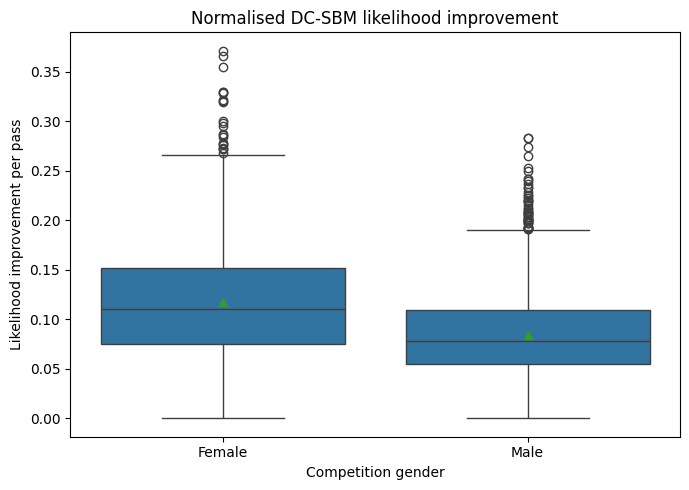

In [ ]:
#Boxplot of the likelihood improvement
plot_df = (
    all_matches_sbm_features[
        [
            "competition_gender",
            "likelihood_improvement_per_pass"
        ]
    ]
    .dropna()
    .copy()
)

plot_df["competition_gender"] = (
    plot_df["competition_gender"].str.capitalize()
)

figure_path = Path(
    "figures/sbm_likelihood_improvement_gender.pdf"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

plt.figure(figsize=(7, 5))

ax = sns.boxplot(
    data=plot_df,
    x="competition_gender",
    y="likelihood_improvement_per_pass",
    order=["Female", "Male"],
    showmeans=True
)


ax.set_xlabel("Competition gender")
ax.set_ylabel("Likelihood improvement per pass")
ax.set_title(
    "Normalised DC-SBM likelihood improvement"
)

plt.tight_layout()

plt.savefig(
    figure_path,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Spearman test on correation between total_passes and likelihood_improvement

analysis_df = (
    all_matches_sbm_features[
        ["total_passes", "likelihood_improvement"]
    ]
    .dropna()
)

rho, p_value = spearmanr(
    analysis_df["total_passes"],
    analysis_df["likelihood_improvement"]
)

print(f"Spearman correlation: {rho:.3f}")
print(f"p-value: {p_value:.4f}")

Spearman correlation: 0.284
p-value: 0.0000


In [ ]:
#Match with highest likelihood_improvement_per_pass

max_position = np.argmax(
    all_matches_sbm_features[
        "likelihood_improvement_per_pass"
    ].to_numpy()
).item()

max_sbm_row = all_matches_sbm_features.iloc[max_position]

max_sbm_row

match_id                                  3911629
team_id                                      3275
team_name                                SD Eibar
competition                        Spain - Liga F
competition_gender                         female
home_dummy                                      1
score                                           0
xg_team_match                            0.160201
number_of_players                              16
initial_log_likelihood                -835.381369
final_log_likelihood                  -785.615249
likelihood_improvement                   49.76612
normalised_final_log_likelihood           -5.8628
number_of_final_blocks                          5
total_passes                                134.0
number_iteration                                2
likelihood_improvement_per_pass          0.371389
players_block                                 3.2
Name: 760, dtype: object

In [77]:
all_matches_sbm_features[all_matches_sbm_features['match_id'] == 3911629]

,match_id,team_id,team_name,competition,competition_gender,home_dummy,score,xg_team_match,number_of_players,initial_log_likelihood,final_log_likelihood,likelihood_improvement,normalised_final_log_likelihood,number_of_final_blocks,total_passes,number_iteration,likelihood_improvement_per_pass,players_block
760,3911629,3275,SD Eibar,Spain - Liga F,female,1,0,0.160201,16,-835.381369,-785.615249,49.766120,-5.862800,5,134.0,2,0.371389,3.2
761,3911629,937,Barcelona WFC,Spain - Liga F,female,0,4,3.023885,16,-6523.430552,-6421.022716,102.407836,-7.878555,5,815.0,3,0.125654,3.2


In [71]:
# set the parameters
match_id = 3911629 
team_id=3275 

# collection of all the matches of that competition
events = sb.events(match_id=match_id)

passes_team_match = create_passes_db(events=events,team_id=team_id)

G_team_match_dist = G_dist_gen(passes=passes_team_match)

# Generation of the average  players position
pos_team_match = player_position(passes=passes_team_match)



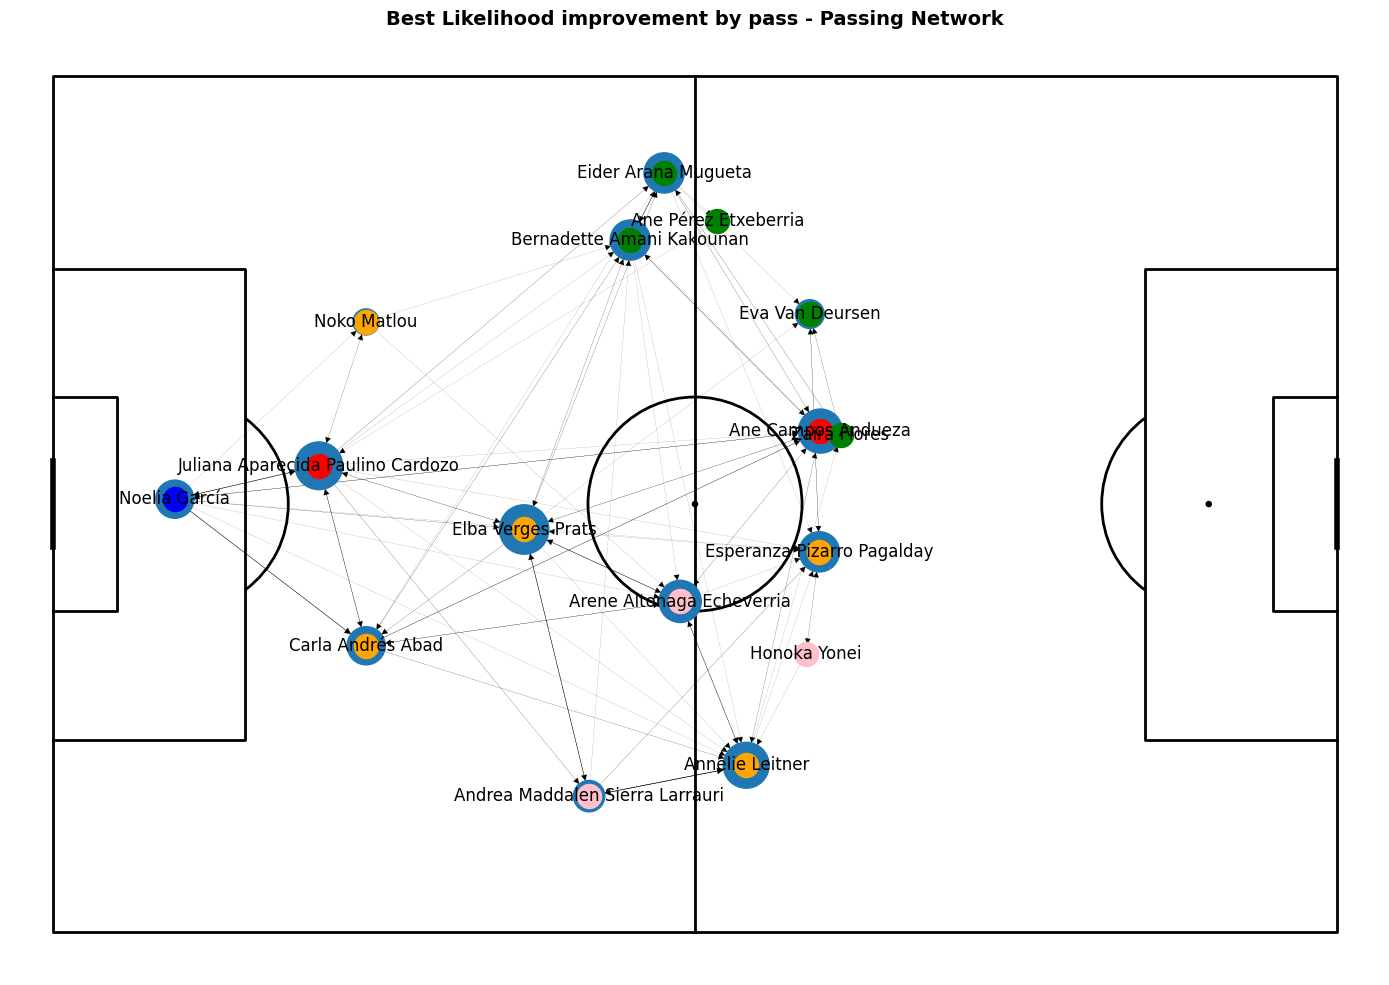

In [75]:
G_team_match_dist_block_list ,G_team_match_dist_partition =  dc_sbm_gn_results(G = G_team_match_dist)

draw_spring(G = G_team_match_dist, pos = pos_team_match, com = G_team_match_dist_partition, label = "Best Likelihood improvement by pass - Passing Network")

## Multi-Match Network Results.

### Clustering

### Men Football

  File "c:\Users\8andr\OneDrive\Desktop\Imperial_College_University\VS_Code\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\8andr\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\8andr\AppData\Local\Programs\Python\Python313\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_grou

Optimal cluster based on Silhouette Score:  2


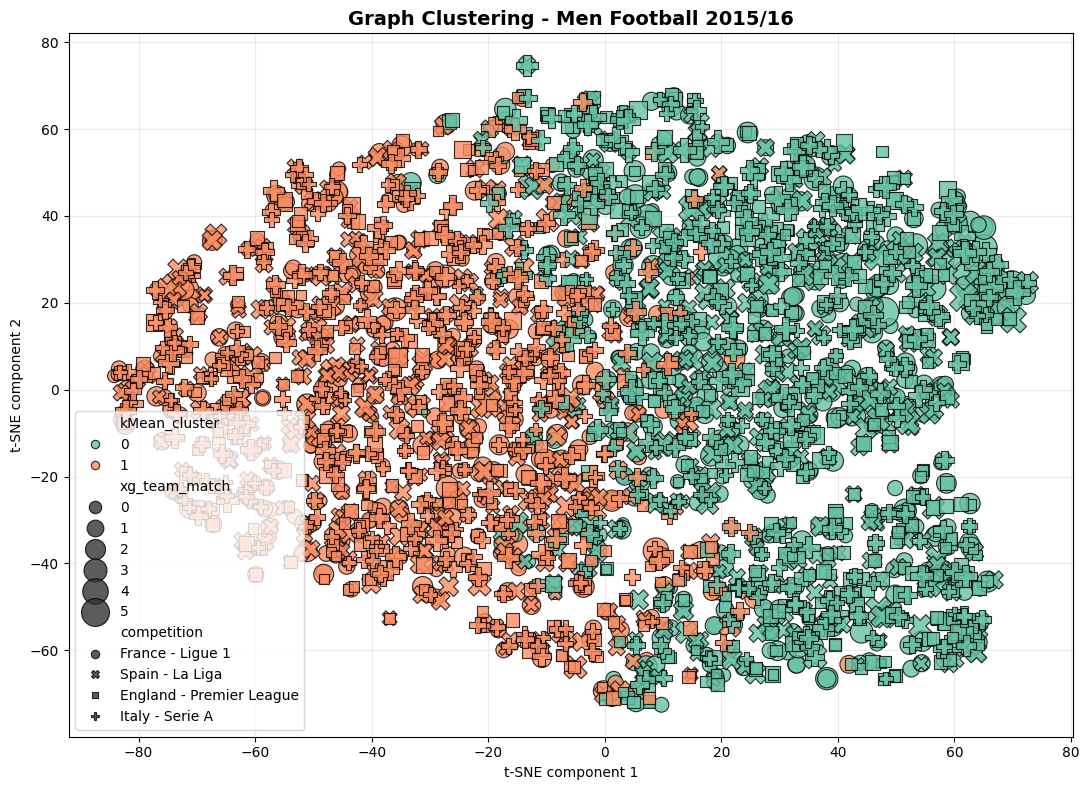

In [12]:
#FEATURES MODEL

#pre work on the data before t-SNE and kMean

features_model =  G_all_matches_dist_male.copy()

X_scaled_features_model_male, feature_cols = embedded_graphs_prep(features_model)

#Cluster Analysis

cluster_eval = evaluate_kmeans_clusters(X_scaled_features_model_male)

print("Optimal cluster based on Silhouette Score: ",cluster_eval['K'][np.argmax(cluster_eval['silhouette_score'])])

labels_feature_model, kmeans_model = clustering_graph(X_scaled_features_model_male, K=2)

tsne_comp = tsne_features(X_scaled_features_model_male)

features_model["kMean_cluster"] = labels_feature_model
features_model["tsne_1"] = tsne_comp[:, 0]
features_model["tsne_2"] = tsne_comp[:, 1]

plot_tsne_kMean_graph_embedded_extend(features_model,
                                      label="Graph Clustering - Men Football 2015/16")

In [11]:
#GATE MODEL

X_all_male, A_all_male, max_nodes_dist = build_graph_dataset(
    matches=all_matches_male, G_gen = G_dist_gen,
)

X_all_scaled_male, feature_scaler = scale_node_features(X_all_male)

X_tensor = tf.convert_to_tensor(X_all_scaled_male, dtype=tf.float32)
A_tensor = tf.convert_to_tensor(A_all_male, dtype=tf.float32)

input_tensor = [X_tensor,A_tensor]


gate_model = GraphAttentionAutoencoder(hidden_dim=64, embedding_dim=128)

optimizer_gate_model = tf.keras.optimizers.Adam(learning_rate=0.001)

losses_gate_model = train_gate(
    model= gate_model,
    optimizer= optimizer_gate_model,
    input_tensor= input_tensor,
    epochs=200
)

Epoch 000 | Loss: 0.7739
Epoch 050 | Loss: 0.6874
Epoch 100 | Loss: 0.6847
Epoch 150 | Loss: 0.6825


Optimal cluster based on Silhouette Score:  2


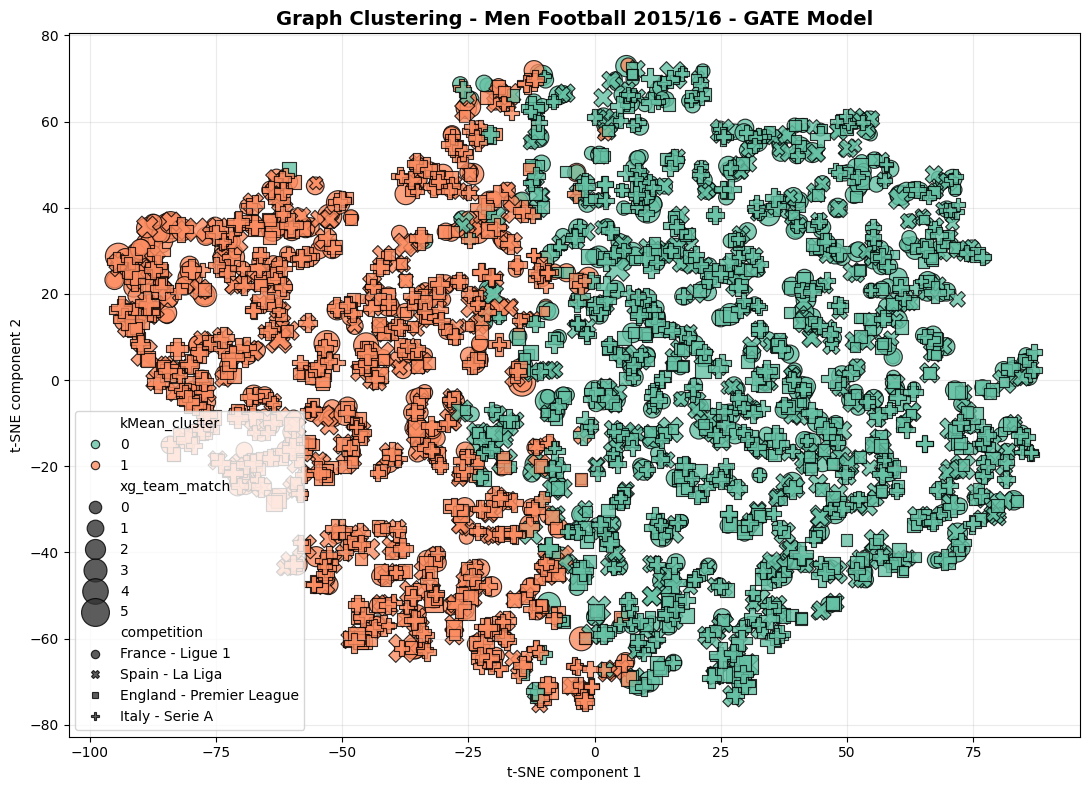

In [25]:
graph_embeddings = gate_model.embed_graphs(
    X_tensor,
    A_tensor
).numpy()

graph_embeddings = pd.DataFrame(
    graph_embeddings,
    columns=[
        f"gate_{i}"
        for i in range(graph_embeddings.shape[1])
    ]
)

graph_embeddings[["match_id", "team_id"]] = G_all_matches_dist_male[["match_id", "team_id"]]

X_scaled_gate, feature_cols = embedded_graphs_prep(graph_embeddings)

#Cluster Analysis

cluster_eval = evaluate_kmeans_clusters(X_scaled_gate)

print("Optimal cluster based on Silhouette Score: ",cluster_eval['K'][np.argmax(cluster_eval['silhouette_score'])])

labels_gate, kmeans_model = clustering_graph(X_scaled_gate, K=2)

tsne_comp = tsne_features(X_scaled_gate)

graph_embeddings["kMean_cluster"] = labels_gate
graph_embeddings["tsne_1"] = tsne_comp[:, 0]
graph_embeddings["tsne_2"] = tsne_comp[:, 1]

graph_embeddings_gate_model = G_all_matches_dist_male.merge(
    graph_embeddings[["kMean_cluster","tsne_1","tsne_2","match_id","team_id"]],
    on=["match_id","team_id"]
)

plot_tsne_kMean_graph_embedded_extend(graph_embeddings_gate_model,
                                      label="Graph Clustering - Men Football 2015/16 - GATE Model")

In [ ]:
#Save GATE model as the best model

# Folder used to store processed datasets
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# File path
features_path = output_dir / "male_graph_embeddings_gate_model.parquet"

# Save dataframe
graph_embeddings_gate_model.to_parquet(
    features_path,
    index=False
)

print(f"Features saved to: {features_path.resolve()}")
print(f"Shape: {graph_embeddings_gate_model.shape}")

Features saved to: C:\Users\8andr\OneDrive\Desktop\Imperial_College_University\AA_2025-26\MATH70105_Machine_Learning_and_Data_Science_Research_Project\zz_Project\01.Code\data\processed\male_graph_embeddings_gate_model.parquet
Shape: (3034, 41)


In [ ]:
#Uploading saved dataframe

features_path = Path("data/processed/male_graph_embeddings_gate_model.parquet")

graph_embeddings_gate_model = pd.read_parquet(features_path)

print(graph_embeddings_gate_model.shape)
graph_embeddings_gate_model.head()

(3034, 41)


,number_of_players,number_of_edges,num_passes,density,average_degree,degree_centralization,average_clustering,modularity,number_of_communities,average_path_length,...,match_id,team_id,team_name,competition,score,home_dummy,competition_gender,kMean_cluster,tsne_1,tsne_2
0,14,115,397,0.631868,16.428571,0.500000,0.864954,0.138568,3,1.831691,...,3901259,133,Troyes,France - Ligue 1,1,1,male,0,-11.111874,71.353363
1,14,128,560,0.703297,18.285714,0.512821,0.853705,0.145153,3,3.353936,...,3901259,147,Olympique de Marseille,France - Ligue 1,1,0,male,1,-67.549164,-3.678075
2,14,125,512,0.686813,17.857143,0.461538,0.880314,0.181123,3,2.627669,...,3900533,129,AS Monaco,France - Ligue 1,1,1,male,1,-69.152390,-24.650791
3,13,93,277,0.596154,14.307692,0.462121,0.799828,0.120930,3,1.737297,...,3900533,140,Stade Malherbe Caen,France - Ligue 1,1,0,male,0,30.269119,-6.027658
4,14,131,540,0.719780,18.714286,0.564103,0.888342,0.107222,2,2.350952,...,3900528,146,Bordeaux,France - Ligue 1,1,1,male,1,-42.947746,-56.572033


In [26]:
#MODEL GATE ADJ

feature_tensor = tf.convert_to_tensor(X_scaled_features_model_male, dtype=tf.float32)

input_tensor = [X_tensor,A_tensor,feature_tensor]


gate_model_adjust = GraphAttentionAutoencoderWithGraphFeatures(n_nodes= max_nodes_dist,hidden_dim=64,node_embedding_dim=128,graph_embedding_dim=128)

optimizer_gate_adj2 = tf.keras.optimizers.Adam(learning_rate=0.001)

losses_gate_model_adjust = train_gate(
    model= gate_model_adjust,
    optimizer= optimizer_gate_adj2,
    input_tensor= input_tensor,
    epochs=200
)

Epoch 000 | Loss: 0.7604
Epoch 050 | Loss: 0.6649
Epoch 100 | Loss: 0.6615
Epoch 150 | Loss: 0.6609


Optimal cluster based on Silhouette Score:  2


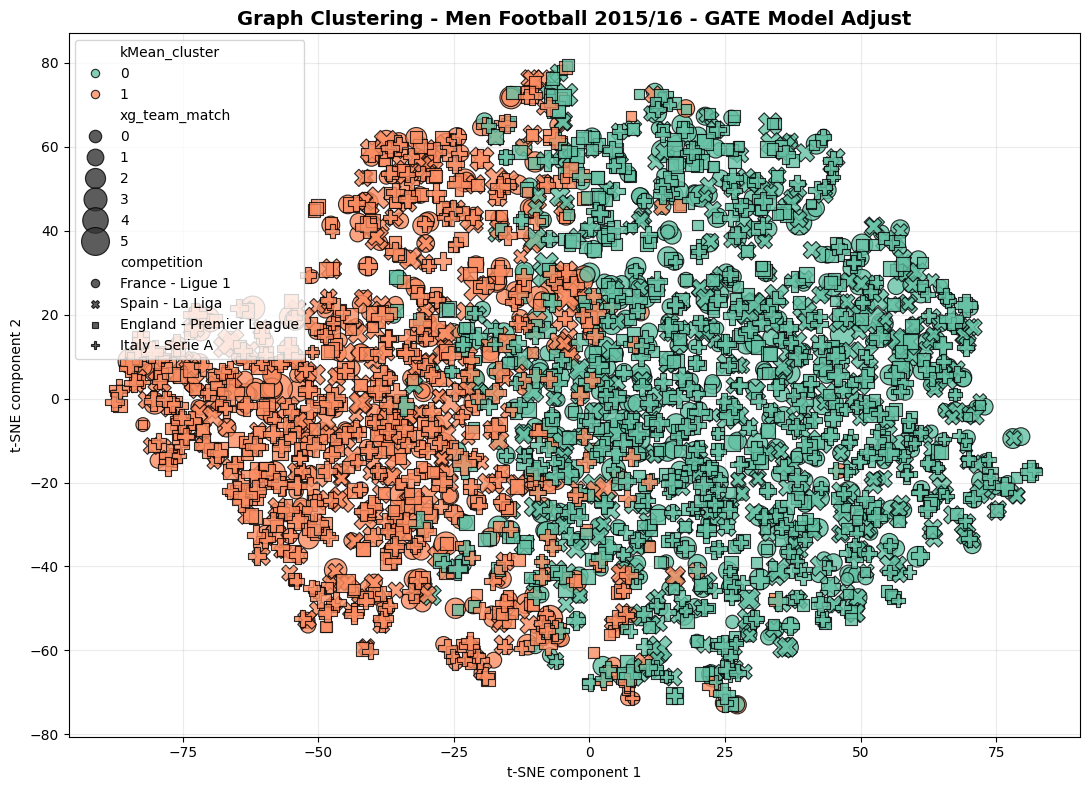

In [27]:
graph_embeddings = gate_model_adjust.embed_graphs([
    X_tensor,
    A_tensor,
    feature_tensor]
).numpy()

graph_embeddings = pd.DataFrame(
    graph_embeddings,
    columns=[
        f"gate_{i}"
        for i in range(graph_embeddings.shape[1])
    ]
)

graph_embeddings[["match_id", "team_id"]] = G_all_matches_dist_male[["match_id", "team_id"]]

X_scaled_gate_adj, feature_cols = embedded_graphs_prep(graph_embeddings)

#Cluster Analysis

cluster_eval = evaluate_kmeans_clusters(X_scaled_gate_adj)

print("Optimal cluster based on Silhouette Score: ",cluster_eval['K'][np.argmax(cluster_eval['silhouette_score'])])

labels_gate_adj, kmeans_model = clustering_graph(X_scaled_gate_adj, K=2)

tsne_comp = tsne_features(X_scaled_gate_adj)

graph_embeddings["kMean_cluster"] = labels_gate_adj
graph_embeddings["tsne_1"] = tsne_comp[:, 0]
graph_embeddings["tsne_2"] = tsne_comp[:, 1]

graph_embeddings_gate_model_adj = G_all_matches_dist_male.merge(
    graph_embeddings[["kMean_cluster","tsne_1","tsne_2","match_id","team_id"]],
    on=["match_id","team_id"]
)

plot_tsne_kMean_graph_embedded_extend(graph_embeddings_gate_model_adj,
                                      label="Graph Clustering - Men Football 2015/16 - GATE Model Adjust")

Optimal cluster based on Silhouette Score:  2


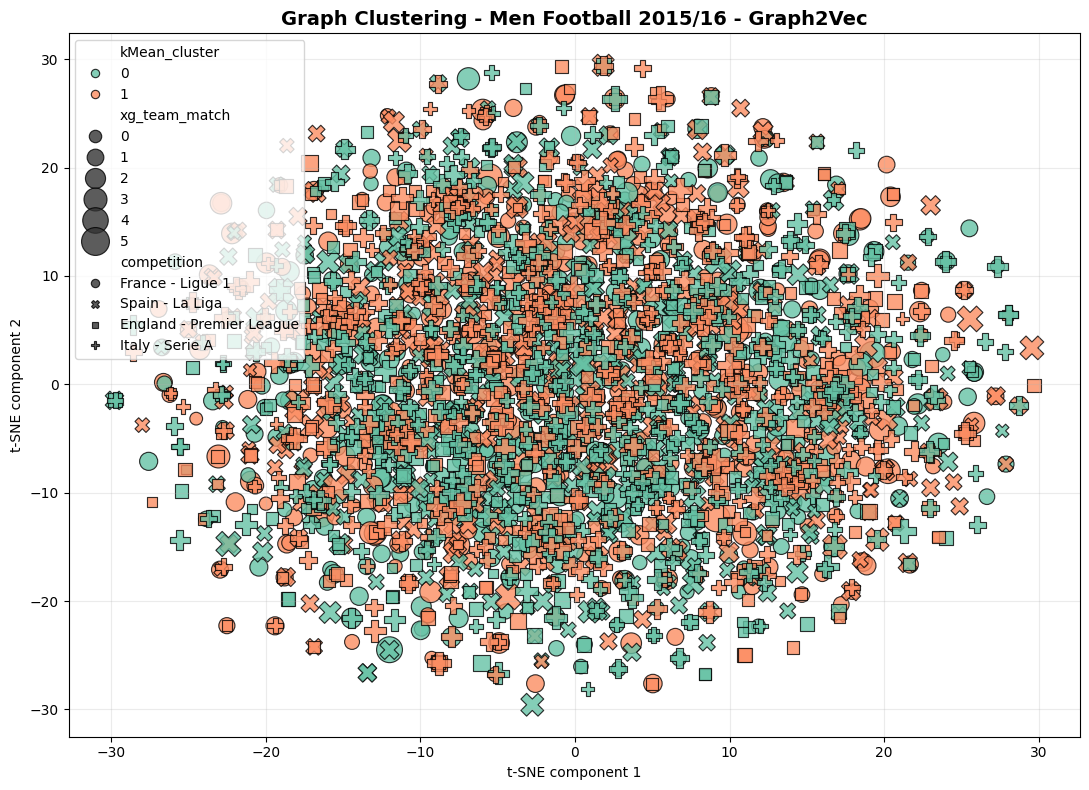

In [28]:
#GRAPH2VEC

# creation of the documents for each graph
documents_graph_dist = build_graph2vec_documents(matches=all_matches_male,G_gen = G_dist_gen)

random_seed = 100

#Doc2Vec embedding algorithm
model_graph2vec_dist = Doc2Vec(documents_graph_dist,vector_size=128,window=0,min_count=1,dm=0,
                epochs=100,seed=random_seed,workers=1
                )

keys = G_all_matches_dist_male["match_id"]*10000 + G_all_matches_dist_male["team_id"]

keys = keys.astype(str).unique()

#extraction of the embedded graph - str(match_id) is the tagged document
embeddings = np.array([
    model_graph2vec_dist.dv[str(keys)] # should follow the same tag logics dv[str(match_id*10000 + team_id)]
    for keys in keys
])

graph_embeddings = pd.DataFrame(
    embeddings,
    columns=[f"g2v_{i}" for i in range(embeddings.shape[1])]
)

graph_embeddings[["match_id", "team_id"]] = G_all_matches_dist_male[["match_id", "team_id"]]

X_scaled_graph2vec, feature_cols = embedded_graphs_prep(graph_embeddings)

#Cluster Analysis

cluster_eval = evaluate_kmeans_clusters(X_scaled_graph2vec)

print("Optimal cluster based on Silhouette Score: ",cluster_eval['K'][np.argmax(cluster_eval['silhouette_score'])])

labels_graph2vec, kmeans_model = clustering_graph(X_scaled_graph2vec, K=2)

tsne_comp = tsne_features(X_scaled_graph2vec)

graph_embeddings["kMean_cluster"] = labels_graph2vec
graph_embeddings["tsne_1"] = tsne_comp[:, 0]
graph_embeddings["tsne_2"] = tsne_comp[:, 1]

graph_embeddings_graph2vec = G_all_matches_dist_male.merge(
    graph_embeddings[["kMean_cluster","tsne_1","tsne_2","match_id","team_id"]],
    on=["match_id","team_id"]
)

plot_tsne_kMean_graph_embedded_extend(graph_embeddings_graph2vec,
                                      label="Graph Clustering - Men Football 2015/16 - Graph2Vec")

In [ ]:
#Model Comparison

result_fatures_model = evaluate_embedding_method(name='Features_Model',X=X_scaled_features_model_male,labels=labels_feature_model)
result_gate_model = evaluate_embedding_method(name='GATE_Model',X=X_scaled_gate,labels=labels_gate)
result_gate_adj_model = evaluate_embedding_method(name='GATE_ADJ_Model',X=X_scaled_gate_adj,labels=labels_gate_adj)
result_graph2vec = evaluate_embedding_method(name='Graph2Vec',X=X_scaled_graph2vec,labels=labels_graph2vec)

#conver the metrics in a pd.DataFrame
result_fatures_model_pd = pd.DataFrame(result_fatures_model, index=[0]).T.rename(columns={0: "value"})[1:]
result_gate_model_pd = pd.DataFrame(result_gate_model, index=[0]).T.rename(columns={0: "value"})[1:]
result_gate_adj_model_pd = pd.DataFrame(result_gate_adj_model, index=[0]).T.rename(columns={0: "value"})[1:]
result_graph2vec_pd = pd.DataFrame(result_graph2vec, index=[0]).T.rename(columns={0: "value"})[1:]

result_fatures_model_pd.columns = [result_fatures_model.get('embedding')]
result_gate_model_pd.columns = [result_gate_model.get('embedding')]
result_gate_adj_model_pd.columns = [result_gate_adj_model.get('embedding')]
result_graph2vec_pd.columns = [result_graph2vec.get('embedding')]

comparison_metrics = pd.concat(
    [result_fatures_model_pd, result_gate_model_pd,result_gate_adj_model_pd,result_graph2vec_pd],
    axis=1
)
comparison_metrics

,Features_Model,GATE_Model,GATE_ADJ_Model,Graph2Vec
silhouette,0.177998,0.294726,0.157855,0.007012
davies_bouldin,1.879407,1.309582,2.087964,11.468264
calinski_harabasz,800.905715,1482.667358,631.716858,22.748533
intra_cluster_distance,4.712246,8.64692,9.986909,11.198931
inter_cluster_distance,5.014611,13.205617,9.56617,1.95303
separation_ratio,1.064166,1.527205,0.957871,0.174394


In [74]:
create_radar_plot2(graph_embeddings_gate_model,label="Tactical Profiles of Passing Network Clusters - GATE Model")

In [35]:
graph_embeddings_gate_model.columns

Index(['number_of_players', 'number_of_edges', 'num_passes', 'density',
       'average_degree', 'degree_centralization', 'average_clustering',
       'modularity', 'number_of_communities', 'average_path_length',
       'betweenness_sd', 'algebraic_connectivity', 'degree_assortativity',
       'triad_003_norm', 'triad_012_norm', 'triad_102_norm', 'triad_021D_norm',
       'triad_021U_norm', 'triad_021C_norm', 'triad_111D_norm',
       'triad_111U_norm', 'triad_030T_norm', 'triad_030C_norm',
       'triad_201_norm', 'triad_120D_norm', 'triad_120U_norm',
       'triad_120C_norm', 'triad_210_norm', 'triad_300_norm', 'entropy_motif',
       'xg_team_match', 'match_id', 'team_id', 'team_name', 'competition',
       'score', 'home_dummy', 'competition_gender', 'kMean_cluster', 'tsne_1',
       'tsne_2'],
      dtype='object')

In [51]:
columns = ['number_of_players',  'num_passes', 'density',
       'average_degree', 'degree_centralization', 'average_clustering',
       'modularity',  'average_path_length',
       'betweenness_sd', 'algebraic_connectivity', 'degree_assortativity','entropy_motif', 'xg_team_match','score','home_dummy','kMean_cluster']

stats_embedding_male=graph_embeddings_gate_model[columns]

In [ ]:
#Table comparison of the cluster

male_cluster_feature_summary = summarize_features_by_gender(
    features_df=stats_embedding_male,
    gender_column="kMean_cluster",
    feature_columns=columns[:-1],
    round_digits=3
)

male_cluster_comparison = create_cluster_comparison_table(male_cluster_feature_summary)

male_cluster_comparison_compact = create_compact_cluster_table(
    male_cluster_comparison,
    decimals=2
)
feature_labels = {
    "number_of_players": "Number of Nodes",
    "num_passes": "Number of Passes",
    "density": "Density",
    "average_degree": "Average Degree",
    "degree_centralization": "Degree Centralization",
    "average_clustering": "Average Clustering",
    "modularity": "Modularity",
    "average_path_length": "Average Path Length",
    "betweenness_sd": "Betweenness SD",
    "algebraic_connectivity": "Algebraic Connectivity",
    "degree_assortativity": "Degree Assortativity",
    "entropy_motif": "Motif Entropy",
    "home_dummy": "Home Match Share",
    "score": "Gol Score",
    "xg_team_match": "Match xG"
}

male_cluster_comparison_compact["feature"] = (
    male_cluster_comparison_compact["feature"]
    .replace(feature_labels)
)


feature_order = [
    "Number of Nodes",
    "Number of Passes",
    "Density",
    "Average Degree",
    "Degree Centralization",
    "Average Clustering",
    "Modularity",
    "Average Path Length",
    "Betweenness SD",
    "Algebraic Connectivity",
    "Degree Assortativity",
    "Motif Entropy",
    "Home Match Share",
    "Gol Score",
    "Match xG"
]

male_cluster_comparison_compact["feature"] = pd.Categorical(
    male_cluster_comparison_compact["feature"],
    categories=feature_order,
    ordered=True
)

male_cluster_comparison_compact = (
    male_cluster_comparison_compact
    .sort_values("feature")
    .reset_index(drop=True)
)
male_cluster_comparison_compact

,feature,Cluster 0 Mean ± SD,Cluster 1 Mean ± SD
0,Number of Nodes,13.71 ± 0.55,13.70 ± 0.56
1,Number of Passes,307.27 ± 69.69,473.02 ± 100.54
2,Density,0.60 ± 0.06,0.65 ± 0.06
3,Average Degree,15.11 ± 1.54,16.45 ± 1.37
4,Degree Centralization,0.60 ± 0.12,0.60 ± 0.11
5,Average Clustering,0.81 ± 0.05,0.84 ± 0.04
6,Modularity,0.12 ± 0.03,0.13 ± 0.03
7,Average Path Length,1.84 ± 0.40,2.56 ± 0.62
8,Betweenness SD,0.10 ± 0.02,0.11 ± 0.02
9,Algebraic Connectivity,2.58 ± 0.79,2.35 ± 0.64


### Women Football

Optimal cluster based on Silhouette Score:  2


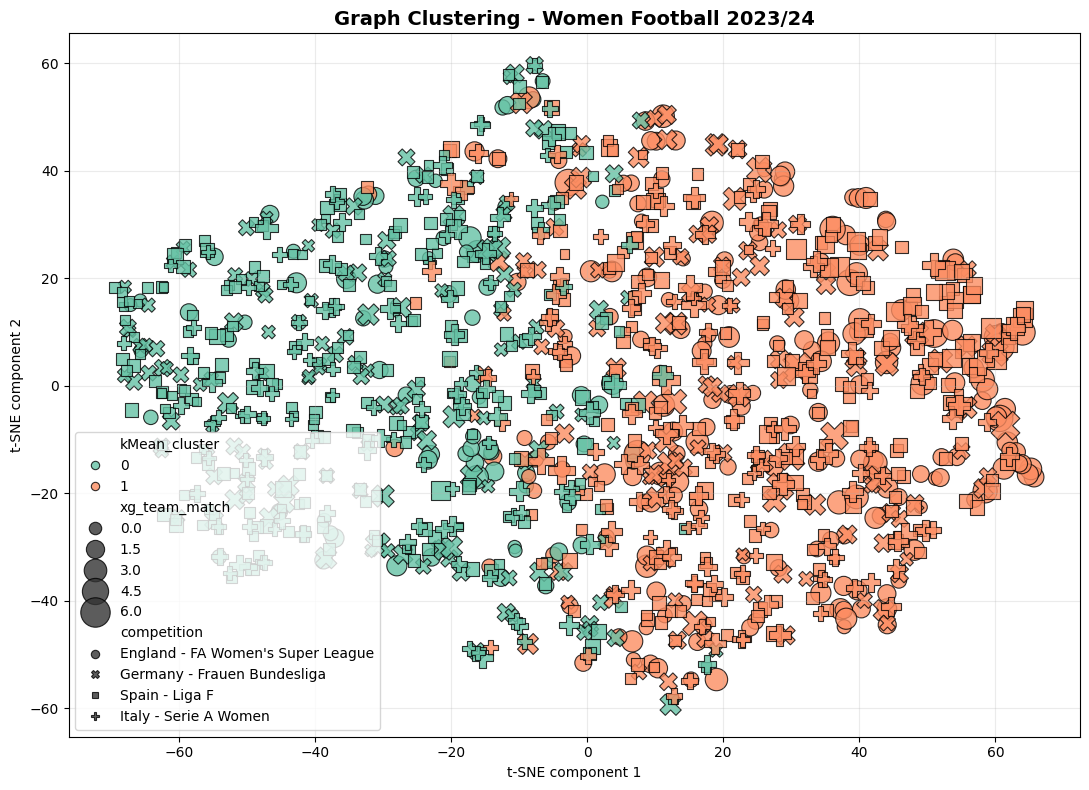

In [12]:
#FEATURES MODEL

#pre work on the data before t-SNE and kMean

features_model_female =  G_all_matches_dist_female.copy()

X_scaled_features_model_female, feature_cols = embedded_graphs_prep(features_model_female)

#Cluster Analysis

cluster_eval = evaluate_kmeans_clusters(X_scaled_features_model_female)

print("Optimal cluster based on Silhouette Score: ",cluster_eval['K'][np.argmax(cluster_eval['silhouette_score'])])

labels_feature_model, kmeans_model = clustering_graph(X_scaled_features_model_female, K=2)

tsne_comp = tsne_features(X_scaled_features_model_female)

features_model_female["kMean_cluster"] = labels_feature_model
features_model_female["tsne_1"] = tsne_comp[:, 0]
features_model_female["tsne_2"] = tsne_comp[:, 1]

plot_tsne_kMean_graph_embedded_extend(features_model_female,
                                      label="Graph Clustering - Women Football 2023/24")

In [13]:
#GATE MODEL

X_all_female, A_all_female, max_nodes_dist = build_graph_dataset(
    matches=all_matches_female, G_gen = G_dist_gen,
)

X_all_scaled_female, feature_scaler = scale_node_features(X_all_female)

X_tensor = tf.convert_to_tensor(X_all_scaled_female, dtype=tf.float32)
A_tensor = tf.convert_to_tensor(A_all_female, dtype=tf.float32)

input_tensor = [X_tensor,A_tensor]


gate_model = GraphAttentionAutoencoder(hidden_dim=64, embedding_dim=128)

optimizer_gate_model_female = tf.keras.optimizers.Adam(learning_rate=0.001)

losses_gate_model = train_gate(
    model= gate_model,
    optimizer= optimizer_gate_model_female,
    input_tensor= input_tensor,
    epochs=200
)

Epoch 000 | Loss: 2.2339
Epoch 050 | Loss: 0.7040
Epoch 100 | Loss: 0.6972
Epoch 150 | Loss: 0.6954


Optimal cluster based on Silhouette Score:  2


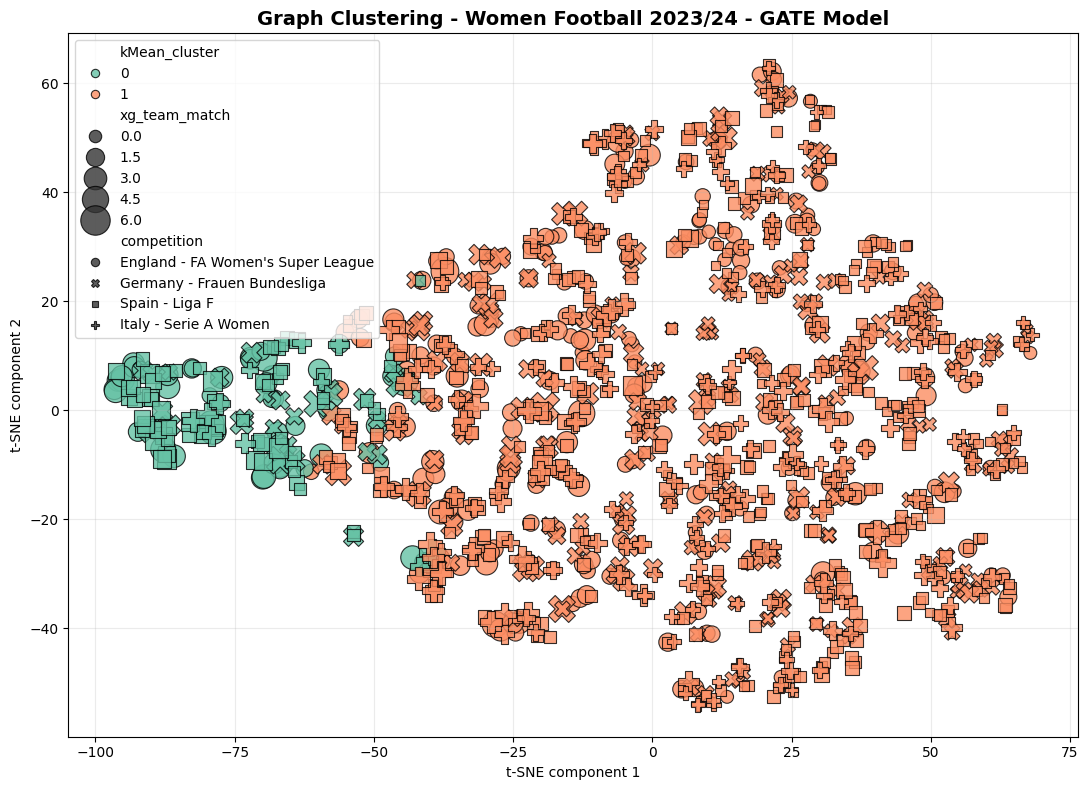

In [73]:
graph_embeddings = gate_model.embed_graphs(
    X_tensor,
    A_tensor
).numpy()

graph_embeddings = pd.DataFrame(
    graph_embeddings,
    columns=[
        f"gate_{i}"
        for i in range(graph_embeddings.shape[1])
    ]
)

graph_embeddings[["match_id", "team_id"]] = G_all_matches_dist_female[["match_id", "team_id"]]

X_scaled_gate, feature_cols = embedded_graphs_prep(graph_embeddings)

#Cluster Analysis

cluster_eval = evaluate_kmeans_clusters(X_scaled_gate)

print("Optimal cluster based on Silhouette Score: ",cluster_eval['K'][np.argmax(cluster_eval['silhouette_score'])])

labels_gate, kmeans_model = clustering_graph(X_scaled_gate, K=2)

tsne_comp = tsne_features(X_scaled_gate)

graph_embeddings["kMean_cluster"] = labels_gate
graph_embeddings["tsne_1"] = tsne_comp[:, 0]
graph_embeddings["tsne_2"] = tsne_comp[:, 1]

graph_embeddings_gate_model_female = G_all_matches_dist_female.merge(
    graph_embeddings[["kMean_cluster","tsne_1","tsne_2","match_id","team_id"]],
    on=["match_id","team_id"]
)

plot_tsne_kMean_graph_embedded_extend(graph_embeddings_gate_model_female,
                                      label="Graph Clustering - Women Football 2023/24 - GATE Model")

In [ ]:
# Folder used to store processed datasets
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

# File path
features_path = output_dir / "female_graph_embeddings_gate_model.parquet"

# Save dataframe of GATE model
graph_embeddings_gate_model_female.to_parquet(
    features_path,
    index=False
)

print(f"Features saved to: {features_path.resolve()}")
print(f"Shape: {graph_embeddings_gate_model_female.shape}")

Features saved to: C:\Users\8andr\OneDrive\Desktop\Imperial_College_University\AA_2025-26\MATH70105_Machine_Learning_and_Data_Science_Research_Project\zz_Project\01.Code\data\processed\female_graph_embeddings_gate_model.parquet
Shape: (1268, 41)


In [ ]:
#Upload the saved dataframe

features_path = Path("data/processed/female_graph_embeddings_gate_model.parquet")

graph_embeddings_gate_model_female = pd.read_parquet(features_path)

print(graph_embeddings_gate_model_female.shape)
graph_embeddings_gate_model_female.head()

(1268, 41)


,number_of_players,number_of_edges,num_passes,density,average_degree,degree_centralization,average_clustering,modularity,number_of_communities,average_path_length,...,match_id,team_id,team_name,competition,score,home_dummy,competition_gender,kMean_cluster,tsne_1,tsne_2
0,16,104,204,0.433333,13.000000,0.533333,0.626123,0.126553,3,1.364610,...,3913082,965,Brighton & Hove Albion WFC,England - FA Women's Super League,2,1,female,1,39.644085,30.597673
1,14,104,457,0.571429,14.857143,0.820513,0.860506,0.159028,3,2.067846,...,3913082,1475,Manchester United W,England - FA Women's Super League,2,0,female,1,-29.800123,-28.129097
2,13,102,429,0.653846,15.692308,0.424242,0.885936,0.142375,3,2.019442,...,3913155,746,Manchester City WFC,England - FA Women's Super League,3,1,female,1,-44.369854,-3.038872
3,14,100,368,0.549451,14.285714,0.602564,0.756597,0.139643,3,1.842819,...,3913155,1475,Manchester United W,England - FA Women's Super League,1,0,female,1,-20.819683,-13.692763
4,16,144,568,0.600000,18.000000,0.838095,0.818317,0.143370,3,2.308337,...,3913167,1475,Manchester United W,England - FA Women's Super League,2,1,female,0,-46.228958,9.910142


In [75]:
#MODEL GATE ADJ

feature_tensor = tf.convert_to_tensor(X_scaled_features_model_female, dtype=tf.float32)

input_tensor = [X_tensor,A_tensor,feature_tensor]


gate_model_adjust = GraphAttentionAutoencoderWithGraphFeatures(n_nodes= max_nodes_dist,hidden_dim=64,node_embedding_dim=128,graph_embedding_dim=128)

optimizer_gate_adj2_female = tf.keras.optimizers.Adam(learning_rate=0.001)

losses_gate_model_adjust = train_gate(
    model= gate_model_adjust,
    optimizer= optimizer_gate_adj2_female,
    input_tensor= input_tensor,
    epochs=200
)

Epoch 000 | Loss: 0.7968
Epoch 050 | Loss: 0.6836
Epoch 100 | Loss: 0.6811
Epoch 150 | Loss: 0.6807


Optimal cluster based on Silhouette Score:  2


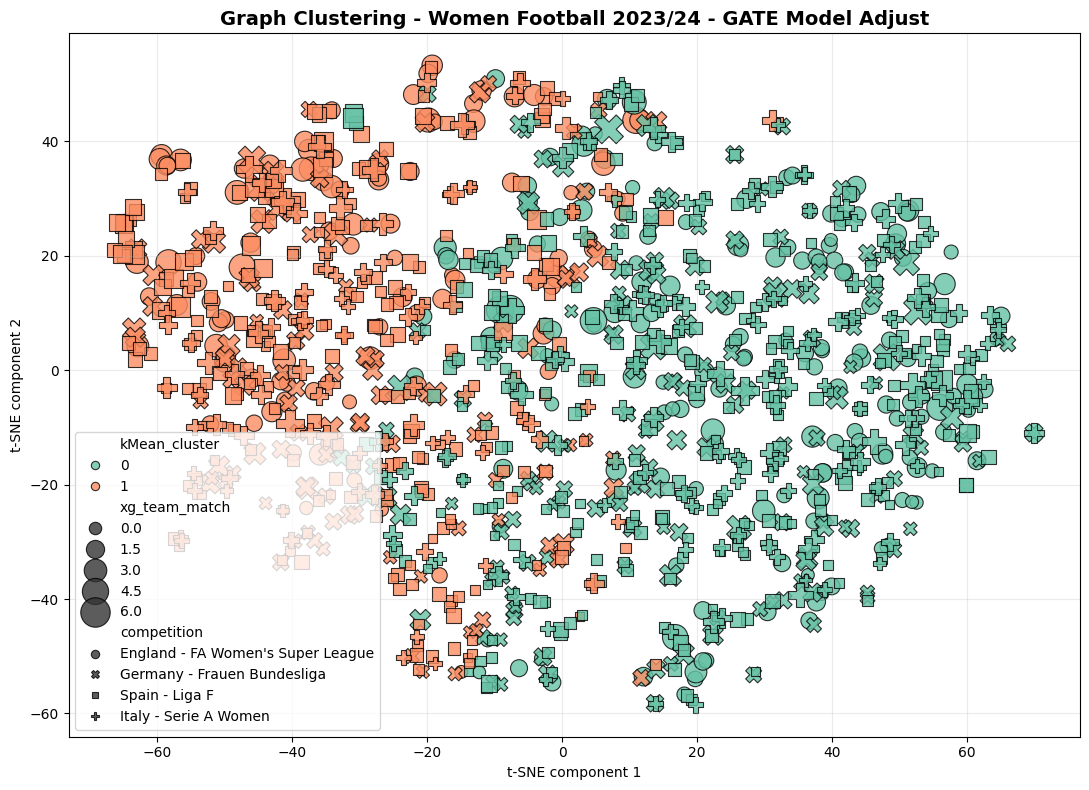

In [ ]:
graph_embeddings = gate_model_adjust.embed_graphs([
    X_tensor,
    A_tensor,
    feature_tensor]
).numpy()

graph_embeddings = pd.DataFrame(
    graph_embeddings,
    columns=[
        f"gate_{i}"
        for i in range(graph_embeddings.shape[1])
    ]
)

graph_embeddings[["match_id", "team_id"]] = G_all_matches_dist_female[["match_id", "team_id"]]

X_scaled_gate_adj, feature_cols = embedded_graphs_prep(graph_embeddings)

#Cluster Analysis

cluster_eval = evaluate_kmeans_clusters(X_scaled_gate_adj)

print("Optimal cluster based on Silhouette Score: ",cluster_eval['K'][np.argmax(cluster_eval['silhouette_score'])])

labels_gate_adj, kmeans_model = clustering_graph(X_scaled_gate_adj, K=2)

tsne_comp = tsne_features(X_scaled_gate_adj)

graph_embeddings["kMean_cluster"] = labels_gate_adj
graph_embeddings["tsne_1"] = tsne_comp[:, 0]
graph_embeddings["tsne_2"] = tsne_comp[:, 1]

graph_embeddings_gate_model_adj_female = G_all_matches_dist_female.merge(
    graph_embeddings[["kMean_cluster","tsne_1","tsne_2","match_id","team_id"]],
    on=["match_id","team_id"]
)

plot_tsne_kMean_graph_embedded_extend(graph_embeddings_gate_model_adj_female,
                                      label="Graph Clustering - Women Football 2023/24 - GATE Adjust Model")

Optimal cluster based on Silhouette Score:  2


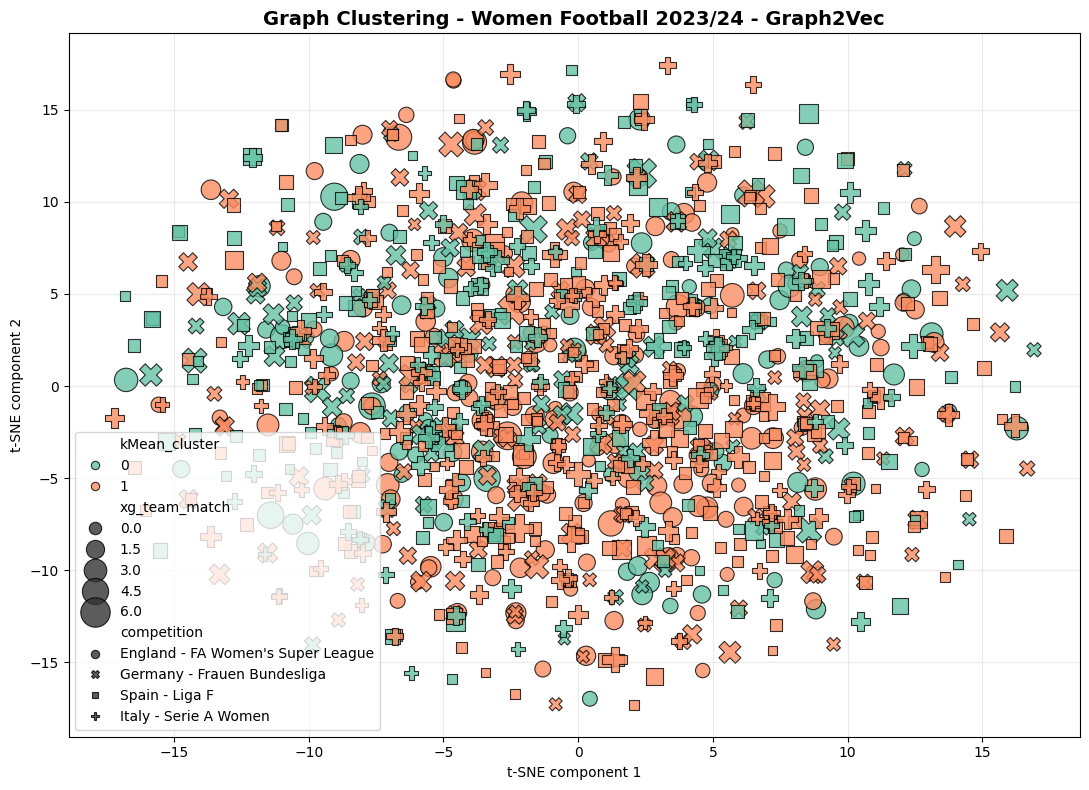

In [77]:
#GRAPH2VEC

# creation of the documents for each graph
documents_graph_dist = build_graph2vec_documents(matches=all_matches_female,G_gen = G_dist_gen)

random_seed = 100

#Doc2Vec embedding algorithm
model_graph2vec_dist = Doc2Vec(documents_graph_dist,vector_size=128,window=0,min_count=1,dm=0,
                epochs=100,seed=random_seed,workers=1
                )

keys = G_all_matches_dist_female["match_id"]*10000 + G_all_matches_dist_female["team_id"]

keys = keys.astype(str).unique()

#extraction of the embedded graph - str(match_id) is the tagged document
embeddings = np.array([
    model_graph2vec_dist.dv[str(keys)] # should follow the same tag logics dv[str(match_id*10000 + team_id)]
    for keys in keys
])

graph_embeddings = pd.DataFrame(
    embeddings,
    columns=[f"g2v_{i}" for i in range(embeddings.shape[1])]
)

graph_embeddings[["match_id", "team_id"]] = G_all_matches_dist_female[["match_id", "team_id"]]

X_scaled_graph2vec, feature_cols = embedded_graphs_prep(graph_embeddings)

#Cluster Analysis

cluster_eval = evaluate_kmeans_clusters(X_scaled_graph2vec)

print("Optimal cluster based on Silhouette Score: ",cluster_eval['K'][np.argmax(cluster_eval['silhouette_score'])])

labels_graph2vec, kmeans_model = clustering_graph(X_scaled_graph2vec, K=2)

tsne_comp = tsne_features(X_scaled_graph2vec)

graph_embeddings["kMean_cluster"] = labels_graph2vec
graph_embeddings["tsne_1"] = tsne_comp[:, 0]
graph_embeddings["tsne_2"] = tsne_comp[:, 1]

graph_embeddings_graph2vec_female = G_all_matches_dist_female.merge(
    graph_embeddings[["kMean_cluster","tsne_1","tsne_2","match_id","team_id"]],
    on=["match_id","team_id"]
)

plot_tsne_kMean_graph_embedded_extend(graph_embeddings_graph2vec_female,
                                      label="Graph Clustering - Women Football 2023/24 - Graph2Vec")

In [ ]:
#Model Comparison

result_fatures_model = evaluate_embedding_method(name='Features_Model',X=X_scaled_features_model_female,labels=labels_feature_model)
result_gate_model = evaluate_embedding_method(name='GATE_Model',X=X_scaled_gate,labels=labels_gate)
result_gate_adj_model = evaluate_embedding_method(name='GATE_ADJ_Model',X=X_scaled_gate_adj,labels=labels_gate_adj)
result_graph2vec = evaluate_embedding_method(name='Graph2Vec',X=X_scaled_graph2vec,labels=labels_graph2vec)

#conver the metrics in a pd.DataFrame
result_fatures_model_pd = pd.DataFrame(result_fatures_model, index=[0]).T.rename(columns={0: "value"})[1:]
result_gate_model_pd = pd.DataFrame(result_gate_model, index=[0]).T.rename(columns={0: "value"})[1:]
result_gate_adj_model_pd = pd.DataFrame(result_gate_adj_model, index=[0]).T.rename(columns={0: "value"})[1:]
result_graph2vec_pd = pd.DataFrame(result_graph2vec, index=[0]).T.rename(columns={0: "value"})[1:]

result_fatures_model_pd.columns = [result_fatures_model.get('embedding')]
result_gate_model_pd.columns = [result_gate_model.get('embedding')]
result_gate_adj_model_pd.columns = [result_gate_adj_model.get('embedding')]
result_graph2vec_pd.columns = [result_graph2vec.get('embedding')]

comparison_metrics_female = pd.concat(
    [result_fatures_model_pd, result_gate_model_pd,result_gate_adj_model_pd,result_graph2vec_pd],
    axis=1
)
comparison_metrics_female

,Features_Model,GATE_Model,GATE_ADJ_Model,Graph2Vec
silhouette,0.17432,0.478896,0.139223,0.011141
davies_bouldin,1.911331,0.975507,2.298554,10.158837
calinski_harabasz,319.125225,673.078003,219.880386,11.424675
intra_cluster_distance,4.71774,9.817375,10.146526,11.16954
inter_cluster_distance,4.936602,20.127737,8.828618,2.19898
separation_ratio,1.046391,2.050216,0.870112,0.196873


In [72]:
create_radar_plot2(graph_embeddings_gate_model_female,label="Tactical Profiles of Passing Network Clusters - GATE Model")

In [81]:
columns = ['number_of_players',  'num_passes', 'density',
       'average_degree', 'degree_centralization', 'average_clustering',
       'modularity',  'average_path_length',
       'betweenness_sd', 'algebraic_connectivity', 'degree_assortativity','entropy_motif', 'xg_team_match','score','home_dummy','kMean_cluster']

stats_embedding_female=graph_embeddings_gate_model_female[columns]

In [ ]:
#Summary Table of the CLusters

female_cluster_feature_summary = summarize_features_by_gender(
    features_df=stats_embedding_female,
    gender_column="kMean_cluster",
    feature_columns=columns[:-1],
    round_digits=3
)

female_cluster_comparison = create_cluster_comparison_table(female_cluster_feature_summary)

female_cluster_comparison_compact = create_compact_cluster_table(
    female_cluster_comparison,
    decimals=2
)

female_cluster_comparison_compact["feature"] = (
    female_cluster_comparison_compact["feature"]
    .replace(feature_labels)
)


female_cluster_comparison_compact["feature"] = pd.Categorical(
    female_cluster_comparison_compact["feature"],
    categories=feature_order,
    ordered=True
)

female_cluster_comparison_compact = (
    female_cluster_comparison_compact
    .sort_values("feature")
    .reset_index(drop=True)
)
female_cluster_comparison_compact

,feature,Cluster 0 Mean ± SD,Cluster 1 Mean ± SD
0,Number of Nodes,15.06 ± 1.15,14.92 ± 1.08
1,Number of Passes,593.96 ± 86.67,321.39 ± 96.85
2,Density,0.60 ± 0.06,0.52 ± 0.07
3,Average Degree,16.85 ± 1.26,14.52 ± 1.83
4,Degree Centralization,0.66 ± 0.13,0.64 ± 0.13
5,Average Clustering,0.82 ± 0.04,0.77 ± 0.06
6,Modularity,0.15 ± 0.03,0.14 ± 0.03
7,Average Path Length,2.50 ± 0.58,1.61 ± 0.41
8,Betweenness SD,0.12 ± 0.02,0.10 ± 0.02
9,Algebraic Connectivity,2.18 ± 0.58,2.23 ± 0.79


## GAT - xG Model

### Men Football

In [15]:
#creation dataloder for the model
xG_team_match_male = G_all_matches_dist_male['xg_team_match']

dataset_xg_male = split_graph_dataset(
    X_all_scaled_male,
    A_all_male,
    X_scaled_features_model_male,
    xG_team_match_male,
    test_size=0.15,
    val_size=0.15,
    random_state=42
)

train_dataset, val_dataset, test_dataset = prepare_dataloaders(dataset_xg_male)

In [19]:
model_gat_xg = GraphAttentionxGRegression(
    hidden_dim= 64,embedding_dim= 32,dense_dim  = 64,dropout_rate = 0.20
    )

model_gat_xg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.MeanSquaredError(name="mse")
    ]
)

early_stopping = [EarlyStopping(monitor='val_loss',patience=20)]

history_gat_xg = model_gat_xg.fit(train_dataset,validation_data=val_dataset,epochs=300,verbose=0,callbacks=early_stopping)

xG_true, xG_pred = predict_xg(model_gat_xg,test_dataset)
gat_report_male = regression_report(xG_true,xG_pred)

gat_report_male

,metric,value
0,MAE,0.536215
1,MSE,0.500938
2,RMSE,0.707769
3,R2,0.120610


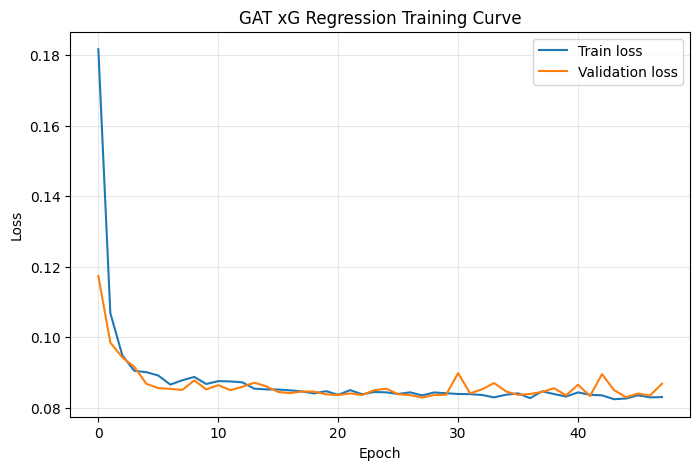

In [20]:
plot_training_history(history_gat_xg)

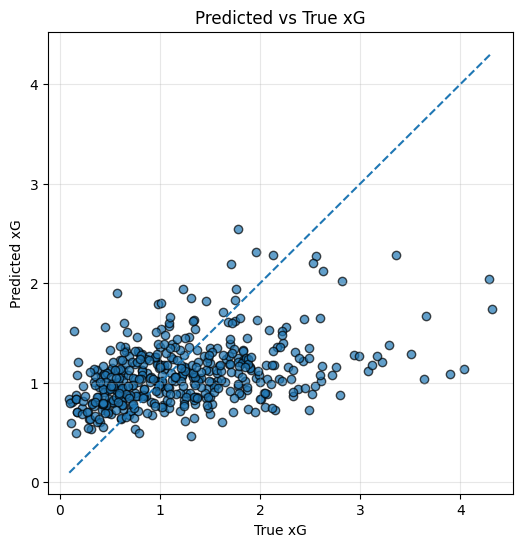

In [21]:
plot_predicted_vs_true(xG_true,xG_pred)

#### BaseLine Models - Ranndom Forest

In [22]:
graph_features_train = dataset_xg_male['G_train']
xg_train = dataset_xg_male['target_train']

graph_features_val = dataset_xg_male['G_val']
xg_val = dataset_xg_male['target_val']

graph_features_test = dataset_xg_male['G_test']
xg_test = dataset_xg_male['target_test']


In [23]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=40
)

rf_model.fit(graph_features_train,np.log1p(xg_train))

rf_pred_log = rf_model.predict(
    graph_features_test
)

rf_pred = np.expm1(rf_pred_log)
rf_pred = np.maximum(rf_pred, 0)

rf_report_male = regression_report(
    xg_test,
    rf_pred
)

rf_report_male

,metric,value
0,MAE,0.573623
1,MSE,0.557628
2,RMSE,0.746745
3,R2,0.021091


In [38]:
gat_report_male["model"] = "GAT"

rf_report_male["model"] = "Random forest"

comparison_report_male = pd.concat(
    [
        gat_report_male,
        rf_report_male
    ],
    ignore_index=True
)


comparison_report_male["competition_gender"] = "Male"

comparison_report_male.pivot(
    index="model",
    columns="metric",
    values="value"
)

metric,MAE,MSE,R2,RMSE
model,,,,
GAT,0.536215,0.500938,0.120610,0.707769
Random forest,0.573623,0.557628,0.021091,0.746745


### Women Football

In [25]:
#creation dataloder for the model
xG_team_match_female = G_all_matches_dist_female['xg_team_match']

dataset_xg_female = split_graph_dataset(
    X_all_scaled_female,
    A_all_female,
    X_scaled_features_model_female,
    xG_team_match_female,
    test_size=0.15,
    val_size=0.15,
    random_state=42
)
train_dataset, val_dataset, test_dataset = prepare_dataloaders(dataset_xg_female)

In [26]:
model_gat_xg = GraphAttentionxGRegression(
    hidden_dim= 64,embedding_dim= 32,dense_dim  = 64,dropout_rate = 0.20
    )

model_gat_xg.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.MeanSquaredError(name="mse")
    ]
)

early_stopping = [EarlyStopping(monitor='val_loss',patience=20)]

history_gat_xg = model_gat_xg.fit(train_dataset,validation_data=val_dataset,epochs=300,verbose=0,callbacks=early_stopping)

xG_true, xG_pred = predict_xg(model_gat_xg,test_dataset)
gat_report_female = regression_report(xG_true,xG_pred)

gat_report_female

,metric,value
0,MAE,0.582978
1,MSE,0.698447
2,RMSE,0.835732
3,R2,0.390303


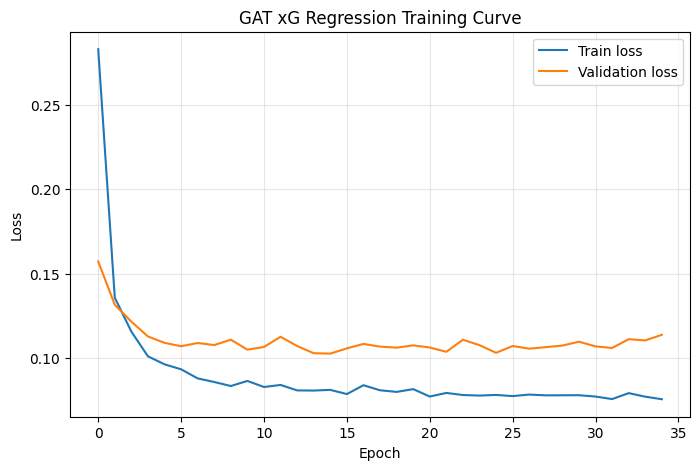

In [27]:
plot_training_history(history_gat_xg)

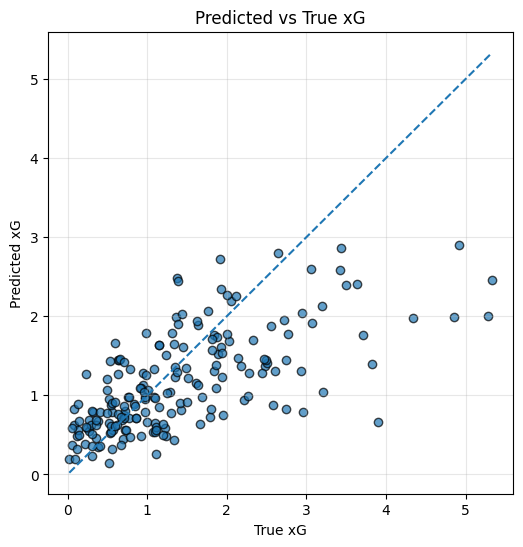

In [28]:
plot_predicted_vs_true(xG_true,xG_pred)

#### BaseLine Models - Ranndom Forest

In [29]:
graph_features_train = dataset_xg_female['G_train']
xg_train = dataset_xg_female['target_train']

graph_features_val = dataset_xg_female['G_val']
xg_val = dataset_xg_female['target_val']

graph_features_test = dataset_xg_female['G_test']
xg_test = dataset_xg_female['target_test']

In [30]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=40
)

rf_model.fit(graph_features_train,np.log1p(xg_train))

rf_pred_log = rf_model.predict(
    graph_features_test
)

rf_pred = np.expm1(rf_pred_log)
rf_pred = np.maximum(rf_pred, 0)

rf_report_female = regression_report(
    xg_test,
    rf_pred
)

rf_report_female

,metric,value
0,MAE,0.654218
1,MSE,0.780117
2,RMSE,0.883243
3,R2,0.319011


In [36]:
gat_report_female["model"] = "GAT"

rf_report_female["model"] = "Random forest"

comparison_report_female = pd.concat(
    [
        gat_report_female,
        rf_report_female
    ],
    ignore_index=True
)

comparison_report_female["competition_gender"] = "Female"

comparison_report_female.pivot(
    index="model",
    columns="metric",
    values="value"
)

metric,MAE,MSE,R2,RMSE
model,,,,
GAT,0.582978,0.698447,0.390303,0.835732
Random forest,0.654218,0.780117,0.319011,0.883243


In [39]:
all_results = pd.concat(
    [comparison_report_male, comparison_report_female],
    ignore_index=True
)

all_results

,metric,value,model,competition_gender
0,MAE,0.536215,GAT,Male
1,MSE,0.500938,GAT,Male
2,RMSE,0.707769,GAT,Male
3,R2,0.120610,GAT,Male
4,MAE,0.573623,Random forest,Male
5,MSE,0.557628,Random forest,Male
6,RMSE,0.746745,Random forest,Male
7,R2,0.021091,Random forest,Male
8,MAE,0.582978,GAT,Female
9,MSE,0.698447,GAT,Female


In [ ]:
#Comparison Table Men & Women Football

results_table = (
    all_results
    .pivot_table(
        index=["competition_gender", "model"],
        columns="metric",
        values="value"
    )
    .reset_index()
)

results_table = results_table[
    [
        "competition_gender",
        "model",
        "MAE",
        "MSE",
        "RMSE",
        "R2"
    ]
]

results_table = results_table.rename(columns={
    "competition_gender": "Gender",
    "model": "Model",
    "R2": "R²"
})

results_table.round(2)

metric,Gender,Model,MAE,MSE,RMSE,R²
0,Female,GAT,0.58,0.70,0.84,0.39
1,Female,Random forest,0.65,0.78,0.88,0.32
2,Male,GAT,0.54,0.50,0.71,0.12
3,Male,Random forest,0.57,0.56,0.75,0.02


In [ ]:
comparison_wide = (
    all_results
    .pivot_table(
        index=["competition_gender", "metric"],
        columns="model",
        values="value"
    )
    .reset_index()
)

comparison_wide["absolute_difference"] = (
    comparison_wide["Random forest"]
    - comparison_wide["GAT"]
)

# For error metrics, positive means GAT has lower error.
comparison_wide["relative_error_reduction_pct"] = np.where(
    comparison_wide["metric"].isin(["MAE", "MSE", "RMSE"]),
    (
        comparison_wide["Random forest"]
        - comparison_wide["GAT"]
    )
    / comparison_wide["Random forest"] * 100,
    np.nan
)

comparison_wide.round(3)

model,competition_gender,metric,GAT,Random forest,absolute_difference,relative_error_reduction_pct
0,Female,MAE,0.583,0.654,0.071,10.889
1,Female,MSE,0.698,0.780,0.082,10.469
2,Female,R2,0.390,0.319,-0.071,NaN
3,Female,RMSE,0.836,0.883,0.048,5.379
4,Male,MAE,0.536,0.574,0.037,6.521
5,Male,MSE,0.501,0.558,0.057,10.166
6,Male,R2,0.121,0.021,-0.100,NaN
7,Male,RMSE,0.708,0.747,0.039,5.219
